# Analytical Velocity

$\
W_{\mathrm{c}} = \frac{2.07 \cdot Ek_c}{R_1} \cdot \mathrm{e}^{\,2.3026 \frac{x}{R_1}}
\
$

$
\text{AV}= Ek_{\text{pump}} + W_c
$

where $AV$ is in $ms^{-1}$ , $e$ is the Euler number and $x$ is the distance to the coast. 

* Wc is computed from the cross-shore Ekman transport evaluated at the coastline, and distributed offshore following an exponential decay over the first baroclinic Rossby radius $R_1$, such that $w_c$ reaches 10% of its coastal value at $x=R_1$ (Bordbar et al. 2021; Fennel 1999).
* Is important to take into consideration that in Boardbar paper, the coastal angle for Benguela is close to $0^{\circ}$ with the North, for which the rotation done is not needed there, and we will use the Uekman non rotated but geographical transport for building this index. However when the rotation is effective the Analytical velocity wouldn't work for the Peruvian Sea which angle is $45^{\circ}$

In [1]:
import xarray as xr
from scipy.ndimage import binary_erosion, binary_dilation
import math
import numpy as np

## Functions

In [2]:
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

## Data

In [3]:
R_X = xr.open_dataset('Rossby_radius_and_X.nc').compute()
mask = coastal_band_mask(R_X, var='R', iterations=10)

In [4]:
R_X = R_X.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5)) 
R_X

<xarray.Dataset> Size: 419kB
Dimensions:  (lat: 134, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    R        (lat, lon) float64 208kB nan nan nan nan nan ... nan nan nan nan
    X        (lat, lon) float64 208kB nan nan nan nan nan ... nan nan nan nan

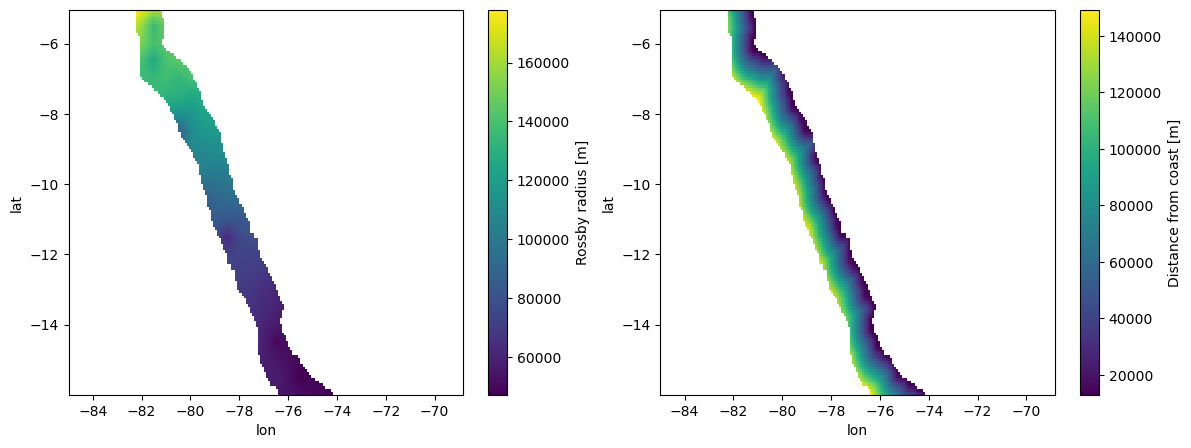

In [5]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize=(14,5))
R_X.R.plot(ax=ax[0])
R_X.X.plot(ax=ax[1])

In [6]:
#### Inshore
valid = xr.where(np.isfinite(R_X.R), 1, 0)
valid_w = valid.shift(lon=-1) #west
# Boolean mask of valid ocean cells
valid_in = xr.where(np.isfinite(R_X.R), 1, 0)
# valid_e = valid.shift(lon=+1)  # east

inshore_mask = (valid_in == 1) & (valid_w == 0)

R_inshore = R_X.R.where(inshore_mask)

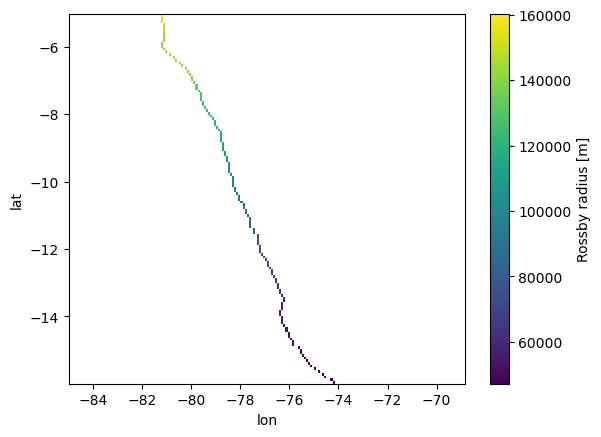

In [7]:
R_inshore.plot()

In [8]:
Uekman_cross = xr.open_dataset('winds_and_components_alpha_30.nc').Inshore_Uekman.sel(
    lon=slice(-85,None),lat=slice(-16,-5)).compute()
Uekman_cross

<xarray.DataArray 'Inshore_Uekman' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

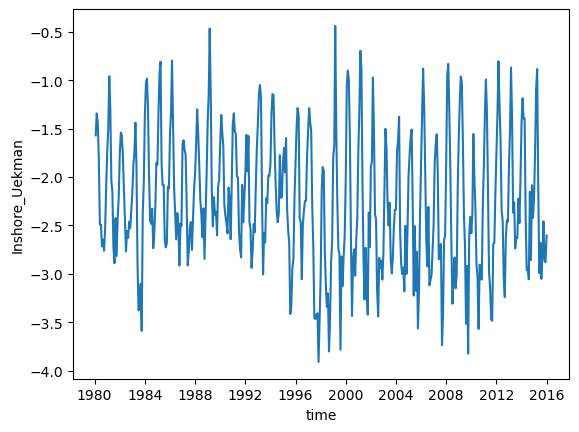

In [9]:
(Uekman_cross*-1).mean(dim=('lon','lat')).plot()

In [10]:
R_X = R_X.mean(dim=('lon'))
R_X

<xarray.Dataset> Size: 3kB
Dimensions:  (lat: 134)
Coordinates:
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    R        (lat) float64 1kB 5.115e+04 5.093e+04 ... 1.621e+05 1.656e+05
    X        (lat) float64 1kB 7.001e+04 6.556e+04 ... 6.301e+04 6.111e+04

In [11]:
e =math.e
r= R_inshore
x= R_X.X
Uek = Uekman_cross

# print(e)
# print(r)
# print(x)
# print(Uek)


In [12]:
Wc = ((2.07 * Uek)/r)*e**(-2.3026*x/r)
Wc #already in m/s

<xarray.DataArray (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

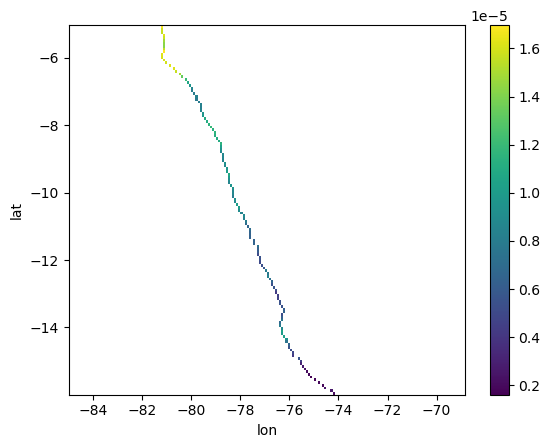

In [13]:
Wc.mean('time').plot()

In [14]:
Pump = xr.open_dataset('Ekman_pumping.nc').compute()
Pump

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 541, time: 432, lon: 601)
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 1GB 2.724e-07 3.15e-07 ... nan nan

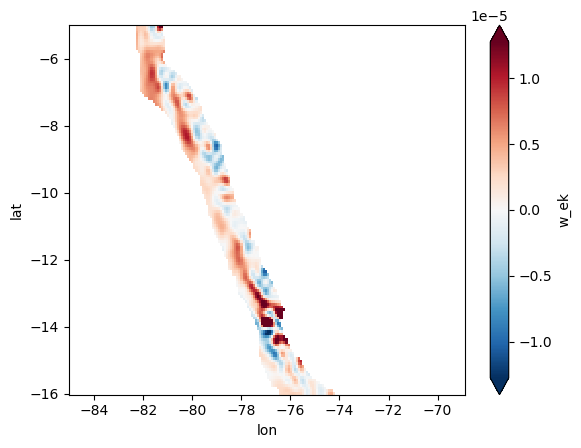

In [15]:
mask_pump = coastal_band_mask(Pump, var='w_ek', iterations=10)
Pump.where(mask_pump).w_ek.sel(lon=slice(-85,None),lat=slice(-16,-5)).mean('time').plot(robust=True)

In [16]:
Ek_pumping = Pump.where(mask_pump).w_ek.sel(lon=slice(-85,None),lat=slice(-16,-5)).mean(dim='lon')
Ek_pumping

<xarray.DataArray 'w_ek' (time: 432, lat: 135)> Size: 467kB
array([[-2.50708811e-07, -5.98516280e-07, -1.08395997e-06, ...,
        -5.73159310e-07,  5.98146646e-07,  1.95101417e-06],
       [ 9.20190060e-07,  5.94229785e-07,  2.09801612e-07, ...,
        -8.36024353e-07,  6.33858938e-08,  1.11428801e-06],
       [ 1.36509949e-06,  9.52045843e-07,  6.01141054e-07, ...,
        -1.34910805e-06, -4.43494157e-07,  1.44324608e-06],
       ...,
       [ 4.56707863e-07, -1.53959337e-07, -6.57258481e-07, ...,
         1.14996320e-06,  2.80728052e-06,  4.42599421e-06],
       [ 5.36379402e-07, -1.63801424e-08, -5.46420868e-07, ...,
         1.76584840e-06,  3.43509468e-06,  4.55331591e-06],
       [-2.51528085e-08, -3.76528272e-07, -7.28300809e-07, ...,
         1.14147066e-06,  2.59149137e-06,  4.30028490e-06]])
Coordinates:
  * lat      (lat) float64 1kB -15.99 -15.91 -15.83 ... -5.2 -5.117 -5.034
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

In [17]:
Ek_pumping = ((Ek_pumping.shift(lat=1) + Ek_pumping)*0.5).dropna('lat') #center to match the Wc lat 
Ek_pumping['lat'] = Wc.lat

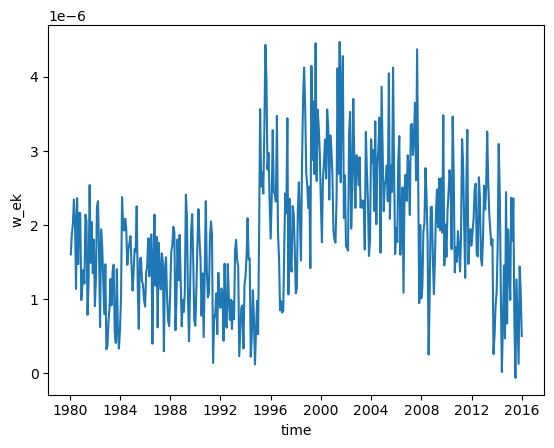

In [18]:
Ek_pumping.mean('lat').plot()

In [19]:
Ek_pumping

<xarray.DataArray 'w_ek' (time: 432, lat: 134)> Size: 463kB
array([[-4.24612545e-07, -8.41238123e-07, -1.19342484e-06, ...,
        -7.96098877e-07,  1.24936683e-08,  1.27458041e-06],
       [ 7.57209922e-07,  4.02015698e-07,  1.11421118e-07, ...,
        -1.04441772e-06, -3.86319230e-07,  5.88836954e-07],
       [ 1.15857267e-06,  7.76593448e-07,  5.52112818e-07, ...,
        -1.37315556e-06, -8.96301101e-07,  4.99875963e-07],
       ...,
       [ 1.51374263e-07, -4.05608909e-07, -5.76882765e-07, ...,
         6.70924439e-07,  1.97862186e-06,  3.61663737e-06],
       [ 2.59999630e-07, -2.81400505e-07, -5.62745280e-07, ...,
         1.14005213e-06,  2.60047154e-06,  3.99420530e-06],
       [-2.00840540e-07, -5.52414541e-07, -7.01985833e-07, ...,
         8.11386141e-07,  1.86648102e-06,  3.44588813e-06]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076

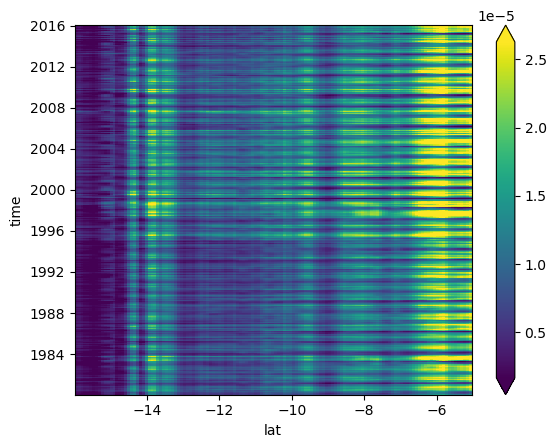

In [20]:
(Ek_pumping + Wc.mean('lon')).plot(robust=True)

In [21]:
AV = Ek_pumping + Wc
AV

<xarray.DataArray (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87

In [22]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

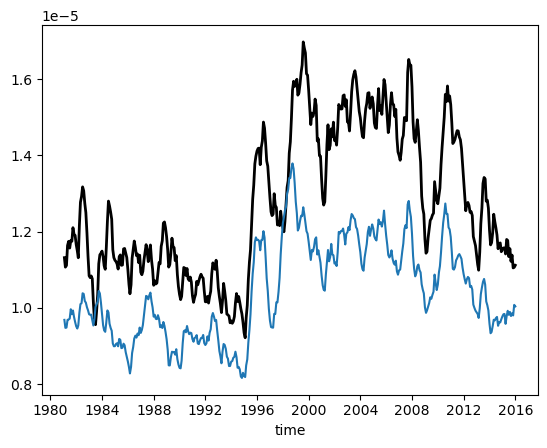

In [23]:
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
(AV).mean(dim=('lat','lon')).rolling(time=13).mean().plot()